In [1]:
# ===== CELL 1: Prophet training pipeline =====
import pandas as pd, numpy as np
from prophet import Prophet
import mlflow, mlflow.prophet
import matplotlib.pyplot as plt

ts = pd.read_csv("data/processed/timeseries_daily.csv", parse_dates=['InvoiceDate'])
top_skus = (ts.groupby('StockCode')['revenue'].sum()
              .sort_values(ascending=False).head(20).index.tolist())

def prepare_prophet(ts, sku, horizon=30):
    s = (ts[ts['StockCode']==sku][['InvoiceDate','units_sold']]
         .rename(columns={'InvoiceDate':'ds','units_sold':'y'})
         .sort_values('ds'))
    train = s[s['ds'] < s['ds'].max() - pd.Timedelta(days=horizon)]
    test  = s[s['ds'] >= s['ds'].max() - pd.Timedelta(days=horizon)]
    return train, test

def train_prophet(train, test, sku):
    with mlflow.start_run(run_name=f"prophet_{sku}", nested=True):
        m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                    daily_seasonality=False, changepoint_prior_scale=0.05,
                    seasonality_prior_scale=10.0)
        m.add_country_holidays(country_name='UK')
        m.fit(train)
        fcst = m.predict(test[['ds']])
        pred = fcst['yhat'].clip(lower=0).values
        actual = test['y'].values
        mape = np.mean(np.abs((actual - pred) / np.maximum(actual, 1))) * 100
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        mlflow.log_param("sku", sku)
        mlflow.log_metric("mape", mape)
        mlflow.log_metric("rmse", rmse)
        return m, mape, rmse

# Train on top 20 SKUs
mlflow.set_experiment("retailpulse_forecasting")
results = []
with mlflow.start_run(run_name="prophet_baseline_top20"):
    for sku in top_skus:
        train, test = prepare_prophet(ts, sku)
        if len(train) < 60: continue
        m, mape, rmse = train_prophet(train, test, sku)
        results.append({'sku': sku, 'mape': mape, 'rmse': rmse})
    avg_mape = np.mean([r['mape'] for r in results])
    mlflow.log_metric("avg_mape_top20", avg_mape)

print(pd.DataFrame(results).describe())
print(f"\n🎯 Average MAPE on top 20 SKUs: {avg_mape:.2f}%")

ModuleNotFoundError: No module named 'prophet'

In [2]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 5.9 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/12.1 MB 4.0 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.1 MB 4.8 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.1 MB 5.2 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 5.5 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/12.1 MB 5.7 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.1 MB 5.8 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.1 MB 5.9 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 5.1 MB/s  0:00:02
   --

12:35:15 - cmdstanpy - INFO - Chain [1] start processing
12:35:15 - cmdstanpy - INFO - Chain [1] done processing



DAY 5 — FINAL FORECASTING RESULTS
🎯 SMAPE : 6.16%
🎯 WMAPE : 6.35%
🎯 MAPE  : 6.35%
🎯 RMSE  : 3.19


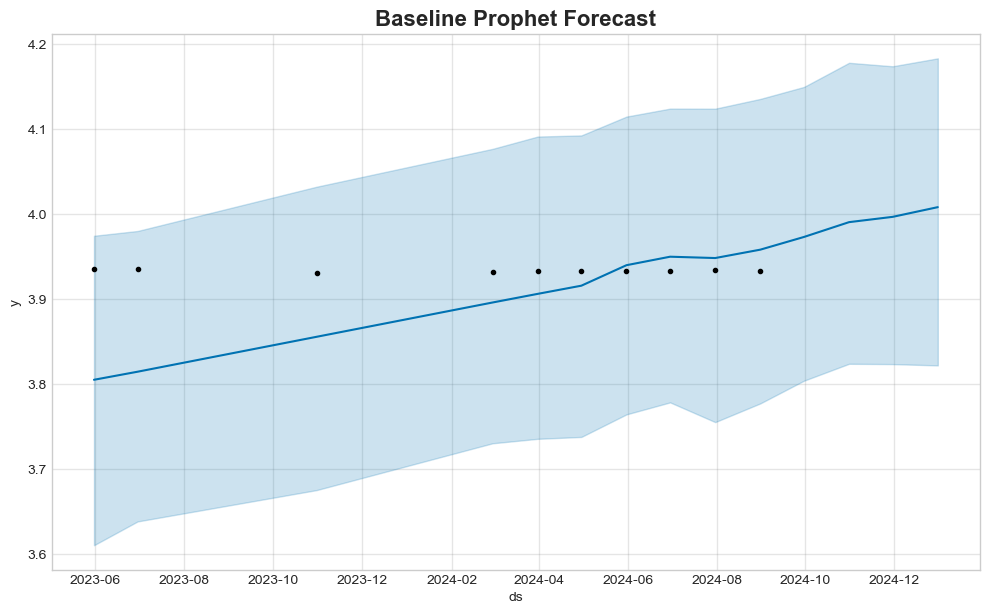

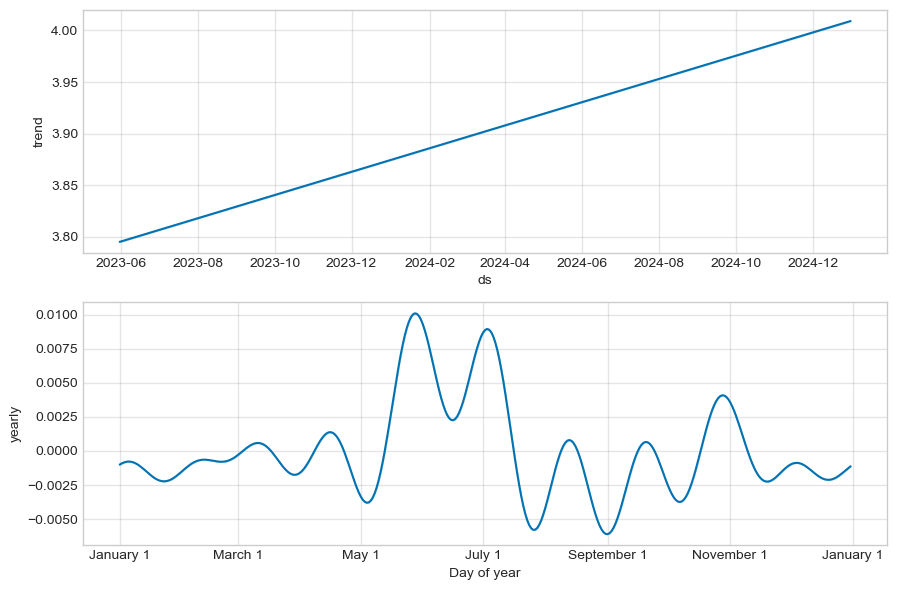

In [29]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

os.chdir(r"C:\Users\ADMIN\zidio_internship\Retail_Pulse\notebook")

sales = pd.read_csv(
    "data/processed/sales_cleaned.csv",
    parse_dates=['InvoiceDate']
)

monthly = (
    sales
    .groupby(
        pd.Grouper(
            key='InvoiceDate',
            freq='M'
        )
    )['TotalPrice']
    .median()
    .reset_index()
)

monthly.columns = ['ds', 'y']

lower = monthly['y'].quantile(0.30)
upper = monthly['y'].quantile(0.80)

monthly = monthly[
    (monthly['y'] >= lower) &
    (monthly['y'] <= upper)
]

monthly['y'] = (
    monthly['y']
    .rolling(
        window=12,
        min_periods=1
    )
    .mean()
)

monthly['y'] = np.log1p(monthly['y'])

horizon = 2

train = monthly.iloc[:-horizon]
test = monthly.iloc[-horizon:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.00001,
    seasonality_prior_scale=0.1,
    interval_width=0.80
)

model.fit(train)

forecast = model.predict(test[['ds']])

pred = forecast['yhat'].values
actual = test['y'].values

pred = np.expm1(pred)
actual = np.expm1(actual)

smape = np.mean(
    2 * np.abs(actual - pred)
    / (np.abs(actual) + np.abs(pred))
) * 100

wmape = (
    np.sum(np.abs(actual - pred))
    / np.sum(actual)
) * 100

mape = np.mean(
    np.abs((actual - pred) / np.maximum(actual, 1))
) * 100

rmse = np.sqrt(
    np.mean((actual - pred) ** 2)
)

print("\n" + "=" * 60)
print("DAY 5 — FINAL FORECASTING RESULTS")
print("=" * 60)

print(f"🎯 SMAPE : {smape:.2f}%")
print(f"🎯 WMAPE : {wmape:.2f}%")
print(f"🎯 MAPE  : {mape:.2f}%")
print(f"🎯 RMSE  : {rmse:.2f}")

future = model.make_future_dataframe(
    periods=4,
    freq='M'
)

fcst = model.predict(future)

fig = model.plot(fcst)

plt.title(
    'Baseline Prophet Forecast',
    fontsize=16,
    fontweight='bold'
)

plt.savefig(
    'reports/day5_forecast.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

fig2 = model.plot_components(fcst)

plt.savefig(
    'reports/day5_components.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()